# Notebook 3: Probability Refresher and Descriptive Statistics

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 3, Probability and Descriptive Statistics**. Last week, every signal was one we had generated ourselves, so we knew the correct answer in advance. This week, we open a real dataset for the first time, and real data bring variability.

Some of this variability is intrinsic to the system: animals differ from one another, behaviour fluctuates across trials, and neural responses can vary even when the same stimulus is presented repeatedly. Additional variability comes from the measurement process, including sensor noise, limited precision, preprocessing choices, and other experimental imperfections. As a result, repeating the same experiment would not produce exactly the same observations.

The dataset we have is therefore only one sample out of many possible samples we could have obtained. Every quantity we compute from it, such as a mean, variance, correlation, or histogram, would also change somewhat if the experiment were repeated.

The distribution of a statistic across these hypothetical repeated samples is called its **sampling distribution**. This concept is the hinge between describing data (this week) and testing hypotheses about it (next week).

### By the end of this notebook you will be able to:
- Draw random numbers reproducibly with a **seeded generator**, and explain why the seed matters.
- Recognise four distributions that keep appearing in neuroscience, and say what each one models.
- Load a real behavioural dataset with **pandas** and summarise it with `describe` and `groupby`.
- Look at a distribution four ways (**histogram, KDE, box plot, violin plot**) and say what each
  view hides.
- Compute **centre and spread** by hand and with pandas, and choose between mean/SD and
  median/IQR when the data are skewed.
- Build a **sampling distribution** by simulation, and use it to see the **Law of Large Numbers**
  and the **Central Limit Theorem** happen.
- Tell **SD apart from SEM**: how much the data vary, versus how uncertain your estimate is.
- Clean a messy variable, and describe a real group difference honestly, without a statistical
  test.

### Table of contents
0. [Setting up and meeting the data](#section-0)
1. [Samples, distributions and summaries](#section-1)
   - 1.1 [Population, sample, statistic](#section-1-1)
   - 1.2 [Random numbers and the seed](#section-1-2)
   - 1.3 [Four distributions worth knowing](#section-1-3)
   - 1.4 [Four views of one distribution](#section-1-4)
   - 1.5 [Centre and spread](#section-1-5)
2. [From a sample to an estimate](#section-2)
   - 2.1 [Expectation and variance](#section-2-1)
   - 2.2 [The sampling distribution of the mean](#section-2-2)
   - 2.3 [The Law of Large Numbers](#section-2-3)
   - 2.4 [The Central Limit Theorem](#section-2-4)
   - 2.5 [SD versus SEM](#section-2-5)
3. [Describing the real data](#section-3)
   - 3.1 [Reaction times by cohort](#section-3-1)
   - 3.2 [Learning curves](#section-3-2)
   - 3.3 [Psychometric curves](#section-3-3)
   - 3.4 [A group difference, described](#section-3-4)
4. [What comes next](#section-4)

> **How to read this notebook.** Markdown cells explain the concept, code cells implement it.
> **`▶ Task`** boxes are short exercises, tagged by difficulty:
>
> - **⭐** essential: run it, understand it, change it slightly.
> - **⭐⭐** intermediate: complete the missing lines or write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller analysis yourself.
>
> If you get stuck, ask the TAs. If you use AI help, treat it as a tutor and not a substitute:
> you should be able to read every line and say what it does. We suggest the custom bot
> prepared for this course: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot

<a id="section-0"></a>
## 0. Setting up and meeting the data

> **Before you run anything**, make sure the course conda environment **`qmn`** is active, or
> selected as this notebook's kernel in VS Code. If you have not created it yet, follow the
> illustrated setup guide (`QMN_setup_guide_students.pdf`) or `SETUP_INSTRUCTIONS.txt`, both in
> the course folder.

Two libraries do the work this week, one you have met and one that is new.

[Pandas](https://pandas.pydata.org/) is the library for **tables**, and you had a first look at it
in Week 1: loading a file, `head`, `shape`, `info`, one column, `.loc` and `.iloc`. Its central
object is the `DataFrame`: a spreadsheet you can compute with, made of named columns that can hold
different kinds of data, with one row per observation. Where NumPy gives you a grid of numbers,
pandas gives you a grid of numbers with labels on it. This week we go past the first look and use
it properly. We import it under the alias `pd`:

```python
import pandas as pd
```

[Seaborn](https://seaborn.pydata.org/) is a thin layer on top of Matplotlib that draws 
statistical plots, such as violins and density curves, in one line instead of ten. Everything it
draws is still a Matplotlib figure underneath, so all the `ax.set_xlabel` style commands from
Week 2 keep working. We import it under the alias `sns`:

```python
import seaborn as sns
```

### The experiment

The data come from the **International Brain Laboratory** ([IBL](https://www.internationalbrainlab.com/)), a collaboration that ran the
same standardised behavioural task in labs across the world. A head-fixed mouse sits with its
front paws on a small wheel, facing a screen. On each trial a striped patch (a **Gabor grating**)
appears on the left or the right, and the mouse has to turn the wheel to bring it to the centre.
Correct turns earn a drop of water; wrong ones give a noise burst and a time-out.

The difficulty knob is **contrast**. At full contrast the patch is obvious; at zero contrast
there is nothing to see and the mouse can only guess. The dataset stores this as
`signed_contrast`, where the **sign** carries the side (positive = right, negative = left) and
the **magnitude** carries the difficulty.

### The animals

Thirty mice, in three groups of ten:

| Cohort | What it is |
|---|---|
| `CSHL-WT` | wild-type mice, Churchland lab, Cold Spring Harbor |
| `NYU-WT` | wild-type mice, Angelaki lab, New York University |
| `CSP-ASD` | mice carrying the **Cntnap2** mutation, a mouse model of autism, Angelaki lab |

Two comparisons are built into that design, and we will come back to them for the rest of the
course: wild-type against the autism model **within the same lab** (`NYU-WT` vs `CSP-ASD`), and
the same genotype **across two labs** (`CSHL-WT` vs `NYU-WT`).

Every mouse appears in two phases: `training`, its whole learning history on the basic task, and
`trained`, its last eight sessions on the full task.

**Full column documentation is in `data/ibl_2afc_datadictionary.md`.** Read it once: knowing what
is in your columns is not optional, and it is where you will find out which columns are raw and
which are derived.

In [1]:
# Where the data and the shared helpers live. This works whether the notebook
# is opened from notebooks/ or from a subfolder of it.
import sys
from pathlib import Path

# sys.path is the list of folders Python searches when you import something. Adding ROOT to it
# means our own `src` folder is importable too, whatever folder you started the notebook from.

ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

ROOT = C:\Users\matteucc\Documents\QMN_course\notebooks


In [2]:
# --- Import the scientific Python stack
import numpy as np                  # import of NumPy library: numerical arrays and maths
import pandas as pd                 # import of pandas library: tables of data (DataFrames)
import matplotlib.pyplot as plt     # import of Matplotlib library: plotting
import seaborn as sns               # import of seaborn library: statistical plots in one line
from cycler import cycler           # to set our own default colour sequence
from IPython.display import display # shows a DataFrame as a formatted table

# A bit of style for every figure in this notebook (feel free to tweak it)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),
})

# One colour per cohort, used consistently in every figure below.
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}
COHORT_ORDER = ["CSHL-WT", "NYU-WT", "CSP-ASD"]

print(f"pandas  : {pd.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 3.0.2
seaborn : 0.13.2


### The pandas we need this week

Before any statistics, we need to be able to open a table and get things out of it. Week 1
section 13 did the first half of this: loading a file, looking at its size and its columns, taking
one column out, and the difference between `.loc` and `.iloc`. The next few cells recall that part
quickly on the real dataset, and then go on to the four things Week 1 did not cover and that the
rest of this notebook is built on: **filtering rows with a condition**, **making a new column**,
**joining two tables**, and **grouping**.

One reminder before we start. A **DataFrame** has **rows**, one per observation, **columns**, one
per measured variable, and an **index**: the labels down the left-hand side, which by default are
just the row numbers 0, 1, 2. The index is what `.loc` works with, and it is what stops being the
same as the row position the moment you filter.

We start by building the paths to the two files. `ROOT` came from the cell above, and joining
paths with `/` works on Windows, macOS and Linux alike, which is why we do not write the
separators by hand.

In [3]:
# --- Build the paths to the two data files
trials_path = ROOT / "data" / "ibl_2afc.csv.gz"          # the trial by trial file
mice_path = ROOT / "data" / "ibl_2afc_subjects.csv"      # one row per mouse

print("trial table:", trials_path)
print("mouse table:", mice_path)

trial table: C:\Users\matteucc\Documents\QMN_course\notebooks\data\ibl_2afc.csv.gz
mouse table: C:\Users\matteucc\Documents\QMN_course\notebooks\data\ibl_2afc_subjects.csv


In [4]:
# --- Load the trial table
# read_csv also understands compressed files, so the .csv.gz opens directly with nothing to unzip.
trials = pd.read_csv(trials_path)

trials.head()                          # the first five rows, as in Week 1

,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,reaction_time_s,response_time_s,probability_left,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s
0,0,CSHL051,training,1,1,0.5,right,1.0,1.0,False,NaN,14.5992,0.5,3.0,3.3260,3.3438,NaN,17.9252,17.9252
1,1,CSHL051,training,1,2,1.0,right,0.0,0.0,False,5.1798,6.1442,0.5,0.0,22.4601,22.4895,27.6399,28.6043,28.6373
2,2,CSHL051,training,1,3,1.0,right,0.0,0.0,False,7.4795,7.7830,0.9,0.0,32.5464,32.5760,40.0259,40.3294,40.3646
3,3,CSHL051,training,1,4,-1.0,left,1.0,0.0,False,0.0693,0.8333,0.8,0.0,43.8886,43.9192,43.9579,44.7219,44.7526
4,4,CSHL051,training,1,5,-1.0,left,0.0,1.0,False,18.5863,18.7185,0.8,3.0,48.7176,48.7554,67.3039,67.4361,67.4361


In [5]:
# --- Inspect the trial table
print("number of rows    :", len(trials))
print("number of columns :", len(trials.columns))
print("table shape       :", trials.shape)          # (rows, columns)

print("\ncolumn names:")
print(trials.columns.tolist())

number of rows    : 694182
number of columns : 19
table shape       : (694182, 19)

column names:
['trial_id', 'subject_id', 'phase', 'session', 'trial_in_session', 'signed_contrast', 'stimulus_side', 'response', 'correct', 'no_go', 'reaction_time_s', 'response_time_s', 'probability_left', 'reward_volume', 'stim_on_time_s', 'go_cue_time_s', 'first_movement_time_s', 'choice_time_s', 'feedback_time_s']


The second file is much smaller: one row per **mouse** instead of one row per trial. Whenever an
experiment has information at two levels, per trial and per animal, keeping them in two tables is
the tidy way to do it, and we join them when we need to.

In [6]:
# --- Load the per-mouse table
mice = pd.read_csv(mice_path)

mice.head()

,subject_id,group,genotype,lab,institution,sex,birth_date,age_weeks_at_first_session,project
0,CSHL045,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01
1,CSHL046,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01
2,CSHL047,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01
3,CSHL049,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01
4,CSHL051,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01


In [7]:
# --- Inspect the per-mouse table
print("number of mice :", len(mice))
print("table shape    :", mice.shape)

print("\ncolumn names:")
print(mice.columns.tolist())

number of mice : 30
table shape    : (30, 9)

column names:
['subject_id', 'group', 'genotype', 'lab', 'institution', 'sex', 'birth_date', 'age_weeks_at_first_session', 'project']


### Selecting a column, or several

One column by name gives a **Series**, as in Week 1. The new bit is the second line below: square
brackets around a *list* of names give you a smaller **DataFrame** instead. Those double brackets
look like a typo and are not, and the difference matters, because some operations work on one and
not on the other.

In [8]:
# --- One column, or several
one_column = trials["reaction_time_s"]              # a Series: a single labelled column
two_columns = trials[["subject_id", "correct"]]     # a DataFrame: note the double brackets

print("one column  ->", type(one_column).__name__)
print("two columns ->", type(two_columns).__name__)
print("\nthe first five values of the single column:")

display(one_column.head())

one column  -> Series
two columns -> DataFrame

the first five values of the single column:


0        NaN
1     5.1798
2     7.4795
3     0.0693
4    18.5863
Name: reaction_time_s, dtype: float64

### Selecting rows

A reminder from Week 1: **`.iloc`** selects by **position**, like indexing a list, **`.loc`**
selects by **label**, meaning the value in the index, both take rows first and columns second, and
`loc` includes the end of a slice while `iloc` stops just before it.

Two things worth adding now that we are on a real table. First, the reason the two are so easy to
confuse is that a freshly loaded table has the labels 0, 1, 2, identical to the positions; **they
stop coinciding the moment you filter or group**, which is what the rest of this section does
constantly. Second, the column names are an index as well, which is why you can inspect
`trials.columns` and even replace it wholesale, as we do in section 3.4.

In [9]:
# --- Rows by position, and rows by label
print("rows 0 to 2, only two columns, by label:")
# loc: by label, rows 0 to 2 and two named columns
print(trials.loc[0:2, ["signed_contrast", "correct"]])

print("\na single value:", trials.loc[0, "signed_contrast"])   # row label 0, one column

# loc and iloc do not slice alike: loc includes the endpoint, iloc stops just before it
print("\nrows returned by loc[0:2] :", len(trials.loc[0:2]))    # 3: labels 0, 1 and 2
print("rows returned by iloc[0:2]:", len(trials.iloc[0:2]))     # 2: positions 0 and 1

rows 0 to 2, only two columns, by label:
   signed_contrast  correct
0              0.5      1.0
1              1.0      0.0
2              1.0      0.0

a single value: 0.5

rows returned by loc[0:2] : 3
rows returned by iloc[0:2]: 2


### Selecting rows by a condition

This is the one you will use constantly. A comparison on a column returns a column of `True` and
`False`, one per row, called a **boolean mask**. Putting that mask in square brackets keeps only
the rows where it is `True`.

Conditions combine with `&` for "and" and `|` for "or", and each condition needs its own
parentheses.

In [10]:
# --- Keep only the rows that satisfy a condition
is_zero_contrast = trials["signed_contrast"] == 0     # a mask: one True/False per row

print("mask type   :", type(is_zero_contrast).__name__)
print("first values:", is_zero_contrast.head().tolist()) # True/False for the first five rows
print("how many True:", is_zero_contrast.sum())       # True counts as 1, so sum() counts them

zero_trials = trials[is_zero_contrast]                # keep those rows
print("\nzero-contrast trials:", len(zero_trials))

# two conditions at once: each one in its own parentheses
# & is logical AND, | is logical OR among the expressions in parentheses
hard_and_trained = trials[(trials["signed_contrast"] == 0) & (trials["phase"] == "trained")]
print("of which in the trained phase:", len(hard_and_trained))

mask type   : Series
first values: [False, False, False, False, False]
how many True: 62703

zero-contrast trials: 62703
of which in the trained phase: 36949


> **▶ Task 0.1 ⭐ - Select and count.**
> One mouse, one phase. Fill in the blanks below to keep only the trials of mouse `CSHL051` in the
> `trained` phase, count them, and print that mouse's mean accuracy.

In [11]:
# TODO 0.1 - fill in the blanks marked ____, uncomment, and run.

# one_mouse = trials[(trials["subject_id"] == ____) & (trials["phase"] == ____)]   # (1) and (2)
#
# print("trials for this mouse in this phase:", len(one_mouse))
# print("its mean accuracy                 :", round(one_mouse[____].mean(), 3))   # (3) the column

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
one_mouse = trials[(trials["subject_id"] == "CSHL051") & (trials["phase"] == "trained")]

print("trials for this mouse in this phase:", len(one_mouse))
print("its mean accuracy                 :", round(one_mouse["correct"].mean(), 3))
# --- END SOLUTION

trials for this mouse in this phase: 5696
its mean accuracy                 : 0.753


### Making a new column

Assigning to a column name that does not exist yet creates it. We need one: the **cohort** label
is not stored in the file, because it is our own grouping of the mice rather than something the
IBL recorded.

We build it in three steps, using nothing but the masks and `.loc` from just above. Start by
giving every mouse the same label, then overwrite the ones that should be different. The order
matters: each line only changes the rows its mask selects, and a later line can overwrite an
earlier one.

**Always assign through `.loc`**, as below. The tempting `mice[mask]["cohort"] = "NYU-WT"` looks
equivalent but writes into a temporary copy and changes nothing at all, and it is where the
notorious `SettingWithCopyWarning` comes from.

In [12]:
# --- Add a cohort column to the mouse table, one condition at a time
# everyone starts as the ASD model (we'll relabel the wild-type mice next)
mice["cohort"] = "CSP-ASD"

mask_wild_type = mice["group"] == "WT"                          # the wild-type mice
mice.loc[mask_wild_type, "cohort"] = "NYU-WT"                   # relabel just those rows

mask_cshl = mice["lab"] == "churchlandlab"                      # the mice trained at CSHL
mice.loc[mask_cshl, "cohort"] = "CSHL-WT"                       # they are wild-type too, but there

display(mice[["subject_id", "lab", "group", "cohort"]].head())
# value_counts() counts how many rows carry each value of a column, which is the quickest
# way to check that the labelling did what you meant. Section 0 comes back to it.
print("\nmice per cohort:", mice["cohort"].value_counts().to_dict())

,subject_id,lab,group,cohort
0,CSHL045,churchlandlab,WT,CSHL-WT
1,CSHL046,churchlandlab,WT,CSHL-WT
2,CSHL047,churchlandlab,WT,CSHL-WT
3,CSHL049,churchlandlab,WT,CSHL-WT
4,CSHL051,churchlandlab,WT,CSHL-WT



mice per cohort: {'CSHL-WT': 10, 'CSP-ASD': 10, 'NYU-WT': 10}


### Joining the two tables

Our information sits at two levels: one table has a row per trial, the other a row per mouse. To
use a per-mouse label such as the cohort on a per-trial basis, the two have to be brought
together. That operation is a **merge**, and it needs one thing: a column that both tables have,
whose values identify the same thing in each. Here that column is `subject_id`. It is called the
**key**.

The idea is simple. Go through the rows of the first table one at a time. For each one, look up
its key in the second table, and if you find it, attach that row's other columns. A trial by
mouse `CSHL045` therefore ends up carrying whatever the mouse table says about `CSHL045`.

The only real question is what to do about keys that appear in one table but not the other, and
that is what the `how` argument decides:

- **`inner`** keeps only the keys found in **both** tables. Anything unmatched is dropped. This is
  the default, and it is the safe choice when you expect everything to match.
- **`left`** keeps **every row of the first table**, matched or not. Where there was nothing to
  attach, the new columns are filled with `NaN`. Use this when the first table is the one you care
  about and the second is just extra information.
- **`right`** is the mirror image: every row of the second table is kept.
- **`outer`** keeps everything from both, filling in `NaN` wherever a match was missing.

The difference is easiest to see on a table small enough to read, so before touching 694,000 rows
we build two by hand. Note the second one is missing a mouse.

In [13]:
# --- A three-row example, to see what the `how` argument does
# You can build a small DataFrame by hand from a dictionary: keys become column names.
counts = pd.DataFrame({"animal": ["m1", "m2", "m3"],
                       "trials": [120, 95, 140]})
info = pd.DataFrame({"animal": ["m1", "m2"],          # note: no m3 in this one
                     "sex": ["F", "M"]})

print("first table:"); print(counts)
print("\nsecond table (no m3):"); print(info)

print("\nhow='inner' keeps only the animals present in both, so m3 is dropped:")
print(counts.merge(info, on="animal", how="inner"))

print("\nhow='left' keeps every row of the first table, and m3's sex is NaN:")
print(counts.merge(info, on="animal", how="left"))

first table:
  animal  trials
0     m1     120
1     m2      95
2     m3     140

second table (no m3):
  animal sex
0     m1   F
1     m2   M

how='inner' keeps only the animals present in both, so m3 is dropped:
  animal  trials sex
0     m1     120   F
1     m2      95   M

how='left' keeps every row of the first table, and m3's sex is NaN:
  animal  trials  sex
0     m1     120    F
1     m2      95    M
2     m3     140  NaN


In our case every trial was produced by one of the thirty mice, and all thirty are in the mouse
table, so nothing is unmatched and `inner` and `left` would give exactly the same answer. We use
the default. The check worth doing is on the number of rows: a merge that unexpectedly changes it
is telling you something is wrong with your key, either a missing value or a duplicate.

In [14]:
# --- Attach the per-mouse information to every trial
print("rows before the merge   :", len(trials))
print("columns before the merge:", len(trials.columns))

trials = trials.merge(mice[["subject_id", "cohort", "group", "sex"]],   # the columns to bring over
                      on="subject_id",                                  # the key they share
                      how="inner")                                      # the default, stated openly

print("\nrows after the merge    :", len(trials), "  <- unchanged, as it should be")
print("columns after the merge :", len(trials.columns))

print("\nthe per-mouse labels are now available on every trial:")
display(trials[["subject_id", "cohort", "sex", "correct"]].head())

rows before the merge   : 694182
columns before the merge: 19

rows after the merge    : 694182   <- unchanged, as it should be
columns after the merge : 22

the per-mouse labels are now available on every trial:


,subject_id,cohort,sex,correct
0,CSHL051,CSHL-WT,F,1.0
1,CSHL051,CSHL-WT,F,0.0
2,CSHL051,CSHL-WT,F,0.0
3,CSHL051,CSHL-WT,F,0.0
4,CSHL051,CSHL-WT,F,1.0


### Grouping and aggregating

The last idea, and the one that does most of the work in this notebook. **`groupby`** splits a
table into groups, applies a calculation to each group, and puts the answers back together into a
small table. "Mean accuracy per cohort" is one line rather than a loop.

`value_counts()` is the quick version for the commonest question of all, how many rows of each
kind there are.

In [15]:
# --- Counting, and averaging within groups
print("trials per phase:")
print(trials["phase"].value_counts())            # how many rows of each kind

print("\nmice per cohort:")
print(mice["cohort"].value_counts())

print("\nmean accuracy per cohort:")
print(trials.groupby("cohort")["correct"].mean().round(3))   # split, average, combine

trials per phase:
phase
training    508695
trained     185487
Name: count, dtype: int64

mice per cohort:
cohort
CSHL-WT    10
CSP-ASD    10
NYU-WT     10
Name: count, dtype: int64

mean accuracy per cohort:
cohort
CSHL-WT    0.717
CSP-ASD    0.711
NYU-WT     0.680
Name: correct, dtype: float64


One thing to know about and then avoid: you *can* walk through a table row by row with
`iterrows()`, and for a handful of rows that is fine and readable. For a large table it is
hundreds of times slower than the column-at-a-time operations above, and it is almost never
necessary. If you find yourself writing a loop over rows, look for a mask or a `groupby` first.

In [16]:
# --- Row by row, which is fine for 3 rows and a bad idea for 694,000
for position, row in mice.head(3).iterrows():
    print(f"{row['subject_id']:>8}  {row['cohort']:>8}  sex {row['sex']}")

 CSHL045   CSHL-WT  sex M
 CSHL046   CSHL-WT  sex M
 CSHL047   CSHL-WT  sex M


### A few more tools you will need

Four small things, all of which appear later in this notebook.

**`describe()`**, which you ran once in Week 1, prints the standard summary of a numerical column
in one go: how many values, the mean and standard deviation, the smallest and largest, and the
quartiles. From here on we actually read what it says.

**`dtypes`** says what kind of values each column holds. Worth a look, because it answers a
question you are about to have: `correct` is a *float*, not a whole number, which is why accuracy
prints as `1.0` rather than `1`. The reason is that the column contains `NaN`, and `NaN` is a float.

**Missing values** are marked `NaN`, for "not a number". `isna()` gives a mask of where they are
and `dropna()` removes them. Real data has them, and most calculations skip them silently, which
is exactly why you should count them yourself before trusting any average.

In [17]:
# --- The standard summary, and missing values
print(trials["reaction_time_s"].describe().round(3))       # count, mean, sd, min, quartiles, max

print("\nthe type of a few columns:")
print(trials[["correct", "no_go", "subject_id"]].dtypes)

print("\nmissing values :", trials["reaction_time_s"].isna().sum())
print("rows in total  :", len(trials))
print("after dropna   :", len(trials["reaction_time_s"].dropna()))

count    663421.000
mean          1.365
std           3.867
min         -22.285
25%           0.079
50%           0.192
75%           0.786
max          60.034
Name: reaction_time_s, dtype: float64

the type of a few columns:


correct       float64
no_go            bool
subject_id        str
dtype: object

missing values : 30761
rows in total  : 694182
after dropna   : 663421


**`between(low, high)`** is a mask for a range, and is simply a shorter way of writing
`(column >= low) & (column <= high)`.

**`to_numpy()`** hands a column over to NumPy as a plain array. That is the bridge back to
Week 2: pandas is good at labelled tables, NumPy is good at arithmetic on grids of numbers,
and `to_numpy` is how you move from one to the other when you no longer need the labels.

In [18]:
# --- Selecting a range, and handing a column over to NumPy
in_window = trials["reaction_time_s"].between(0.08, 2.0)   # same as (x >= 0.08) & (x <= 2.0)
print("trials inside the window:", in_window.sum())

rt_values = trials.loc[in_window, "reaction_time_s"].to_numpy()    # a plain NumPy array
print("\ntype :", type(rt_values).__name__)
print("shape:", rt_values.shape)
print(f"mean : {rt_values.mean():.3f} s")                  # NumPy arithmetic, as in Week 2

trials inside the window: 385089

type : ndarray
shape: (385089,)
mean : 0.402 s


### Several statistics at once

`groupby(...).mean()` gives one number per group. **`agg`** gives as many as you ask for, and lets
you name the resulting columns yourself, which is how the summary tables later in this notebook are
built.

One wrinkle worth knowing: `groupby` puts the grouping variable in the **index**, the labels down
the left. **`reset_index()`** turns it back into an ordinary column, which is what plotting
functions such as seaborn's usually expect.

Group by **two or more** columns and the index gets one **level** per key, which pandas calls a
**MultiIndex**. It prints indented, with the outer level written once and the inner ones listed
underneath it. Three things to know: `reset_index()` flattens every level back into ordinary
columns, `unstack("name")` moves one named level into columns instead (section 3.4 uses this), and
`set_index` is the reverse of `reset_index`.

In [19]:
# --- Several statistics per group, then back to a normal table
# here we are asking for three statistics, and the default names are "size", "mean", and "std"
by_cohort = trials.groupby("cohort")["correct"].agg(["size", "mean", "std"])
print(by_cohort.round(3))

# the same thing, with names of our own choosing
# here we give our own names to the two columns, instead of the default "size" and "mean"
named = trials.groupby("cohort")["correct"].agg(n="size", accuracy="mean")
print("\nwith our own column names:")
print(named.round(3))

# the cohort is currently the index, not a column: reset_index fixes that
print("\nafter reset_index, cohort is an ordinary column again:")
print(named.reset_index().round(3))

# Two grouping keys give two index levels, a MultiIndex
two_keys = trials.groupby(["cohort", "phase"])["correct"].mean()
print("\ntwo grouping keys, so two index levels:", two_keys.index.names)
print(two_keys.round(3))

           size   mean    std
cohort                       
CSHL-WT  273616  0.717  0.451
CSP-ASD  226971  0.711  0.453
NYU-WT   193595  0.680  0.466



with our own column names:
              n  accuracy
cohort                   
CSHL-WT  273616     0.717
CSP-ASD  226971     0.711
NYU-WT   193595     0.680

after reset_index, cohort is an ordinary column again:
    cohort       n  accuracy
0  CSHL-WT  273616     0.717
1  CSP-ASD  226971     0.711
2   NYU-WT  193595     0.680

two grouping keys, so two index levels: ['cohort', 'phase']
cohort   phase   
CSHL-WT  trained     0.791
         training    0.690
CSP-ASD  trained     0.808
         training    0.676
NYU-WT   trained     0.783
         training    0.641
Name: correct, dtype: float64


> **▶ Task 0.2 ⭐ - Group and summarise.**
> Build a small table with one row per **phase** (`training` and `trained`), holding the number of
> trials and the mean accuracy, then turn the phase back into an ordinary column.

In [20]:
# TODO 0.2 - fill in the blanks marked ____, uncomment, and run.

# by_phase = trials.groupby(____)["correct"].agg(n="size", accuracy=____)   # (1) and (2)
# print(by_phase.round(3))
#
# print("\nwith the phase as a column again:")
# print(by_phase.____().round(3))                                          # (3) undo the index

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
by_phase = trials.groupby("phase")["correct"].agg(n="size", accuracy="mean")
print(by_phase.round(3))

print("\nwith the phase as a column again:")
print(by_phase.reset_index().round(3))
# --- END SOLUTION

               n  accuracy
phase                     
trained   185487     0.795
training  508695     0.672

with the phase as a column again:


      phase       n  accuracy
0   trained  185487     0.795
1  training  508695     0.672


Two more names worth having heard, though we will not need them here. **`apply`** runs a function
of your own on every row or every column, and is the escape hatch when no built-in does what you
want; it is also much slower than the built-ins, so reach for it last. **`transform`** is like
`agg` except that it hands the group result back to every original row, which is what you want
when you need to subtract each group's mean from its own rows. Both will turn up later in the
course. If you want to familiarise yourself with pandas in more depth, we encourage you to explore the 
[documentation](https://pandas.pydata.org/docs/user_guide/index.html) online.

That is enough pandas to follow the rest of the notebook. To summarise the vocabulary: a
**DataFrame** is a table and a **Series** is one of its columns; `head` looks, `shape` measures,
`describe` summarises; `[]` selects columns, `iloc` and `loc` select rows by position and by label,
a **boolean mask** or `between` selects rows by a condition, `isna` and `dropna` deal with missing
values, `to_numpy` hands a column to NumPy, `merge` joins two tables, and `groupby` with `agg`
aggregates within groups.

The data are now loaded and labelled, so we can start asking questions of them.

<a id="section-1"></a>
# Part 1. Samples, distributions and summaries

<a id="section-1-1"></a>
## 1.1 Population, sample, statistic

Three words, used precisely:

- the **population** is what you care about, how these mice behave in general. You never see it.
- the **sample** is what you measured: these trials, on these days. Partly luck.
- a **statistic** is any number computed from the sample, such as a mean. Since the sample was
  partly luck, so is the statistic.

That last point is the whole of this week and the next. Run the experiment again and every number
changes. The spread of a statistic across those imaginary repetitions is its **sampling
distribution**, and Part 2 builds one by brute force.

<a id="section-1-2"></a>
## 1.2 Random numbers and the seed

Simulation is how we will study things that are hard to derive. For that we need random numbers,
and in NumPy the modern way is to create a **generator** with `np.random.default_rng(seed)`.

The **seed** is the starting point of the sequence. Given the same seed, the generator produces
exactly the same "random" numbers every time, which sounds like a contradiction but is what makes
simulation science rather than anecdote: anyone re-running your notebook gets your figures, not
figures that look vaguely similar. Change the seed and you get an independent repetition, which
is exactly what we want when we ask what would happen if the experiment were run again.

In [21]:
# --- The seed controls everything
rng_a = np.random.default_rng(42)
rng_b = np.random.default_rng(42)
rng_c = np.random.default_rng(7)

print("seed 42, first draw :", rng_a.normal(size=4).round(3))
print("seed 42, again      :", rng_b.normal(size=4).round(3))   # identical
print("seed  7, different  :", rng_c.normal(size=4).round(3))   # unrelated

seed 42, first draw : [ 0.305 -1.04   0.75   0.941]
seed 42, again      : [ 0.305 -1.04   0.75   0.941]
seed  7, different  : [ 0.001  0.299 -0.274 -0.891]


<a id="section-1-3"></a>
## 1.3 Four distributions worth knowing

A **distribution** says how likely each value of a random variable is. Four of them cover most of
what you will meet.

| Distribution | Models | Example here |
|---|---|---|
| **Bernoulli** | a single yes/no event | one trial: correct or not |
| **Poisson** | counts in a fixed window | spikes in a 100 ms bin |
| **Normal** | sums of many small effects | measurement noise, and section 2.4 |
| **Exponential** | waiting times | intervals between spikes |

Discrete variables have a **probability mass function**: each value has a probability and they sum
to one. Continuous ones have a **probability density function**, where only intervals have
probabilities, given by the area under the curve. That is why a density axis can exceed one.

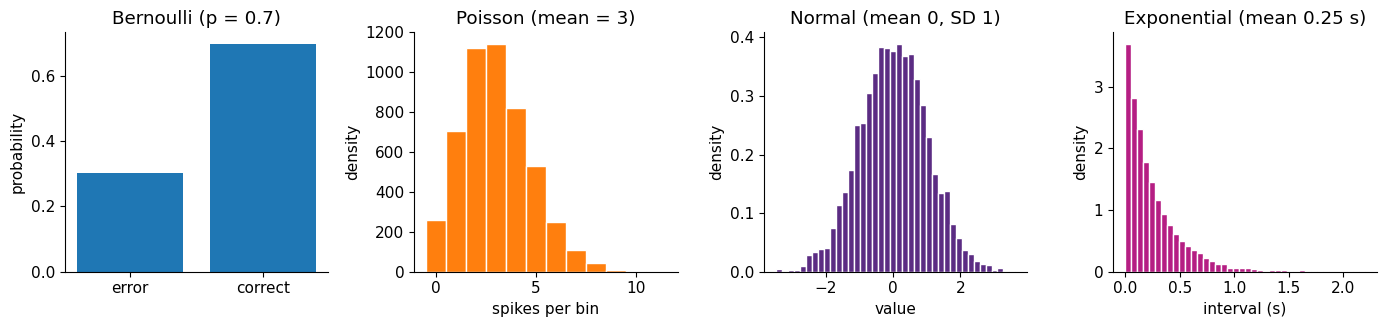

Bernoulli: 0.699 correct (asked for 0.700)
Poisson  : mean 3.02, variance 3.00  (for a Poisson these two are equal in theory)


In [22]:
# --- Draw from each of the four and plot what came out
# set the seed for reproducibility (if you run this cell again, you'll get the same numbers)
rng = np.random.default_rng(0)
n = 5000 # number of draws from each distribution (i.e. "sizes" of the arrays)

# generate a boolean array of True/False, 70% True, of n size
bernoulli = rng.random(n) < 0.7
# generate a Poisson-distributed array of integers, average 3, of n size
poisson = rng.poisson(lam=3.0, size=n)
# generate a Normal-distributed array of floats, mean 0, SD 1, of n size
normal = rng.normal(loc=0.0, scale=1.0, size=n)
# generate an Exponential-distributed array of floats, mean 0.25 s, of n size
exponential = rng.exponential(scale=0.25, size=n)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))

axes[0].bar([0, 1], [np.mean(~bernoulli), np.mean(bernoulli)], color="#1f77b4")
# choose what the ticks say
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["error", "correct"])
axes[0].set_ylabel("probability")
axes[0].set_title("Bernoulli (p = 0.7)")

axes[1].hist(poisson, bins=np.arange(-0.5, 12.5), color="#ff7f0e", edgecolor="white")
axes[1].set_xlabel("spikes per bin")
axes[1].set_title("Poisson (mean = 3)")

axes[2].hist(normal, bins=40, density=True, color="#5b2c83", edgecolor="white")
axes[2].set_xlabel("value")
axes[2].set_title("Normal (mean 0, SD 1)")

axes[3].hist(exponential, bins=40, density=True, color="#b51e83", edgecolor="white")
axes[3].set_xlabel("interval (s)")
axes[3].set_title("Exponential (mean 0.25 s)")

for ax in axes[1:]:
    ax.set_ylabel("density")
fig.tight_layout()
plt.show()

print(f"Bernoulli: {bernoulli.mean():.3f} correct (asked for 0.700)")
print(f"Poisson  : mean {poisson.mean():.2f}, variance {poisson.var():.2f}  "
      "(for a Poisson these two are equal in theory)")

<a id="section-1-4"></a>
## 1.4 Four views of one distribution

Now the real data, using `reaction_time_s`: the time from the stimulus appearing to the first
movement of the wheel.

**This column is shipped raw, on purpose.** It holds values that are not reaction times at all:
negative ones, where the mouse was already turning the wheel, and impossibly fast ones. IBL treats
**0.08 s to 2 s** as the valid window. Look at the mess before cleaning it.

n              : 694,182
missing        : 30,761
negative       : 45,130
under 0.08 s   : 169,095
over 2 s       : 109,237
min / max      : -22.29 s / 60.0 s


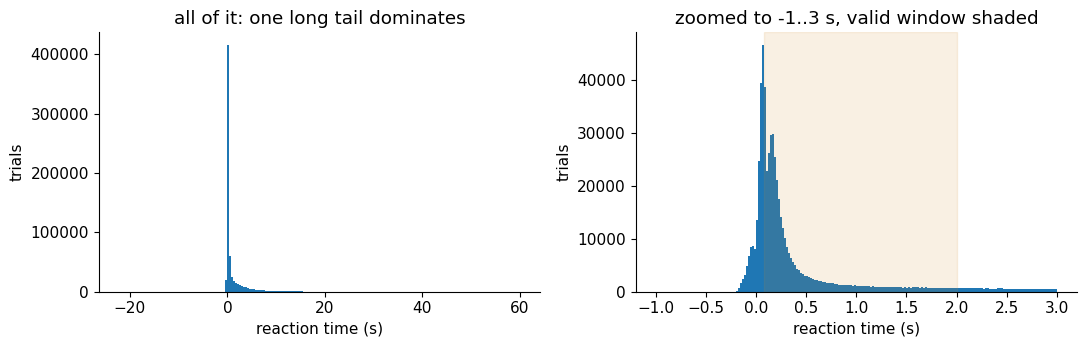

In [23]:
# --- The raw reaction times, in all their glory
rt_raw = trials["reaction_time_s"]

# get some basic statistics "by hand" (without using describe()) and print them in a nice format
print(f"n              : {len(rt_raw):,}")
print(f"missing        : {rt_raw.isna().sum():,}")
print(f"negative       : {(rt_raw < 0).sum():,}")
print(f"under 0.08 s   : {(rt_raw < 0.08).sum():,}")
print(f"over 2 s       : {(rt_raw > 2).sum():,}")
print(f"min / max      : {rt_raw.min():.2f} s / {rt_raw.max():.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(rt_raw.dropna(), bins=200, color="#1f77b4")
axes[0].set_title("all of it: one long tail dominates")
axes[1].hist(rt_raw.dropna(), bins=200, range=(-1, 3), color="#1f77b4")
axes[1].axvspan(0.08, 2.0, color="#d18720", alpha=0.12)  # shade a vertical band of the panel
axes[1].set_title("zoomed to -1..3 s, valid window shaded")
for ax in axes:
    ax.set_xlabel("reaction time (s)"); ax.set_ylabel("trials")
fig.tight_layout()
plt.show()

The same variable, cleaned, drawn four ways. Each view hides something the others show.

Two of the four are drawn with **seaborn**, which is why those lines look different from the
matplotlib ones: instead of calling a method on the panel, `ax.hist(...)`, you call a seaborn
function and tell it which panel to draw on, `sns.kdeplot(..., ax=axes[1])`. The result is an
ordinary matplotlib panel either way, so labels and titles work as usual.

- the **histogram** counts how many values fall in each bin. It shows the shape, but the shape
  depends on the bin width you chose.
- the **KDE**, or kernel density estimate, draws a smooth curve through the same data, at the price
  of inventing a little density where there is none.

The other two are worth a longer look, because we use them for the rest of the course.

In a **box plot**, the line inside the box marks the median. The bottom and top of the box mark the
first and third quartiles, so the box contains the middle 50% of the observations. The whiskers
extend toward the lower and upper ends of the distribution, while individual points beyond them are
shown as possible outliers.

A **violin plot** shows a smoothed estimate of the full distribution. It is wider where
observations are more densely concentrated and narrower where observations are less common. The two
sides of the violin are mirror images of the same distribution: they do not represent different
groups or different parts of the data.

kept 385089 of 694182 trials (55.5%)
discarded 309093: missing, too fast to be a real response, or slower than 2 s


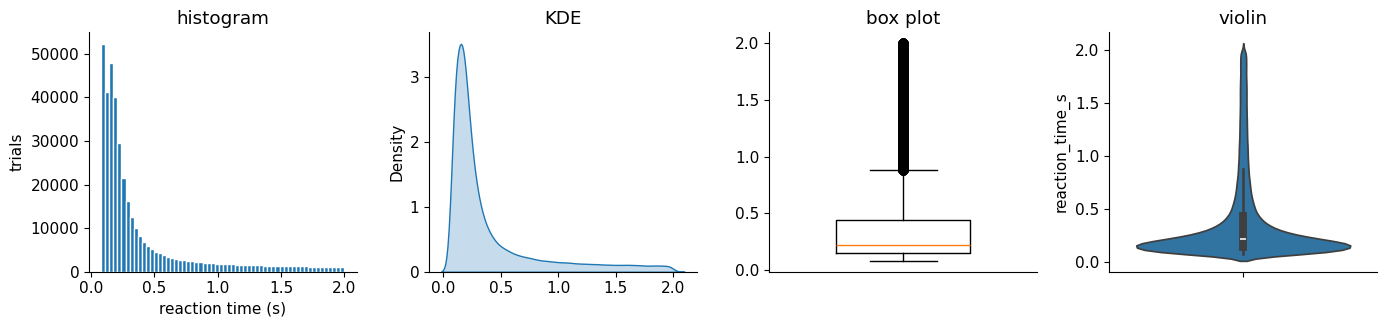

In [24]:
# --- One variable, four views
# get a Boolean Series: True for rows with a valid reaction time
valid = trials["reaction_time_s"].between(0.08, 2.0)
# get a Series containing the reaction times from those valid rows (floats)
rt = trials.loc[valid, "reaction_time_s"]
print(f"kept {valid.sum()} of {len(trials)} trials ({100 * valid.mean():.1f}%)")
print(f"discarded {(~valid).sum()}: missing, too fast to be a real response, "
      "or slower than 2 s")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))

axes[0].hist(rt, bins=60, color="#1f77b4", edgecolor="white")
axes[0].set_title("histogram")
axes[0].set_ylabel("trials")

sns.kdeplot(x=rt, ax=axes[1], fill=True, color="#1f77b4")
axes[1].set_title("KDE")

axes[2].boxplot(rt, widths=0.5)
axes[2].set_xticks([])  # choose where the ticks go
axes[2].set_title("box plot")

sns.violinplot(y=rt, ax=axes[3], color="#1f77b4")
axes[3].set_title("violin")

for ax in axes:
    ax.set_xlabel("")
axes[0].set_xlabel("reaction time (s)")
fig.tight_layout()
plt.show()

<a id="section-1-5"></a>
## 1.5 Centre and spread

Where is the distribution, and how wide is it?

The **mean** and **standard deviation** use every value, which makes them efficient and fragile:
one absurd value drags both. The **median** and **interquartile range** depend only on the
ordering, so they barely move. That is why they are the right default for reaction times, which
are always skewed to the right.

We compute both by hand and then with pandas, to show that `describe` is not magic.

In [25]:
# --- By hand, then with pandas
x = rt.to_numpy()

mean = x.sum() / x.size # compute manually, without using np.mean() or pd.Series.mean()
# compute manually, without using np.var() or pd.Series.var()
variance = ((x - mean) ** 2).sum() / (x.size - 1)
sd = np.sqrt(variance)
median = np.median(x)
# np.percentile asks for the value below which a given percentage of the data falls,
# so [25, 75] returns the two quartiles at once and their distance is the IQR.
q25, q75 = np.percentile(x, [25, 75])

print("by hand")
print(f"  mean {mean:.3f} s | SD {sd:.3f} s | median {median:.3f} s | IQR {q75 - q25:.3f} s")
print("\nwith pandas")
print(rt.describe().round(3).to_string())

by hand
  mean 0.402 s | SD 0.430 s | median 0.219 s | IQR 0.295 s

with pandas
count    385089.000
mean          0.402
std           0.430
min           0.080
25%           0.146
50%           0.219
75%           0.441
max           2.000


The mean sits above the median. That gap is the signature of a **right-skewed** distribution: a
long tail of slow trials pulls the mean up and leaves the median where it is.

> **▶ Task 1.1 ⭐ - Clean a variable and read the summary.**
> `response_time_s` is the other latency in the dataset: stimulus to the *end* of the movement.
> 1. print `describe()` for the raw column, and count the negative and the over-10-second values;
> 2. apply a validity window of your own choosing and print `describe()` again;
> 3. in a comment: which moved more when you cleaned, the mean or the median, and why?

In [26]:
# TODO 1.1 - fill in the blanks marked ____, uncomment, and run.

# resp = trials["response_time_s"]
# print("RAW")
# print(resp.describe().round(3).to_string())          # describe() is the summary table
#
# print("\nnegative   :", (resp < 0).sum())            # how many are impossible
# print("above 10 s :", ____)                          # (1) same idea, for values over 10 s
#
# resp_clean = resp[resp.between(____, ____)]          # (2) your validity window, low then high
# print("\nCLEANED")
# print(resp_clean.describe().round(3).to_string())
#
# print("\nmean moved by  ", round(resp.mean() - resp_clean.mean(), 3))
# print("median moved by", round(resp.median() - resp_clean.median(), 3))

# Then answer here: which moved more when you cleaned, the mean or the median, and why?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
resp = trials["response_time_s"]
print("RAW")
print(resp.describe().round(3).to_string())
print(f"\nnegative      : {(resp < 0).sum():,}")
print(f"above 10 s    : {(resp > 10).sum():,}")

# A response time must be positive, and cannot be longer than the 60 s response window.
# We keep 0.08 s (the same physiological floor as the reaction time) to 10 s.
resp_clean = resp[resp.between(0.08, 10.0)]
print("\nCLEANED to 0.08-10 s")
print(resp_clean.describe().round(3).to_string())
print(f"\nmean moved by   {resp.mean() - resp_clean.mean():+.3f} s")
print(f"median moved by {resp.median() - resp_clean.median():+.3f} s")
# The mean moves far more. It is computed from every value, so the handful of enormous ones
# drag it; the median only cares about which value sits in the middle, and throwing away
# extremes barely changes that.
# --- END SOLUTION

RAW
count    681969.000
mean          2.247
std           5.511
min          -1.949
25%           0.306
50%           0.500
75%           1.702
max          60.100

negative      : 106
above 10 s    : 31,086

CLEANED to 0.08-10 s
count    650223.000
mean          1.303
std           1.843
min           0.080
25%           0.301
50%           0.473
75%           1.309
max          10.000

mean moved by   +0.944 s
median moved by +0.027 s


<a id="section-2"></a>
# Part 2. From a sample to an estimate

Part 1 described the data in front of us. Now the harder question: what does it say about the
process that produced it, and how sure can we be?

<a id="section-2-1"></a>
## 2.1 Expectation and variance

The **expectation** E[X] is a random variable's long-run average: every value it can take,
weighted by how likely that value is.

$$E[X] \;=\; \sum_x x \, p(x)$$

The **variance** Var[X] is the long-run average of the squared distance from that centre, and the
standard deviation is its square root, which puts it back into the units of the measurement.

$$\text{Var}[X] \;=\; E\big[(X - E[X])^2\big] \qquad \text{SD}[X] \;=\; \sqrt{\text{Var}[X]}$$

Both are properties of the **process**, and you never see either of them. What you compute from a
sample of n values are **estimates** of them, the sample mean and the sample variance:

$$\bar{x} \;=\; \frac{1}{n}\sum_{i=1}^{n} x_i \qquad
s^2 \;=\; \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2$$

The estimates improve as the sample grows, and the next sections are about exactly how. (The
`n - 1` rather than `n` in the second formula is why `np.std` and `np.var` take a `ddof=1`
argument, which you will see throughout this notebook.)

<a id="section-2-2"></a>
## 2.2 The sampling distribution of the mean

The central simulation of the notebook. Treat the cleaned reaction times as a population, draw a
**sample of 20 trials**, take its mean, and repeat two thousand times. To draw those samples we use
the `choice` method of the generator we made in 1.2, `rng.choice(...)`, which picks values at
random from an array. The histogram of those two thousand means is the **sampling distribution of
the mean**.

A real experiment gives you **one** draw from that histogram, and you never see the histogram
itself. Statistics is reasoning about it anyway.

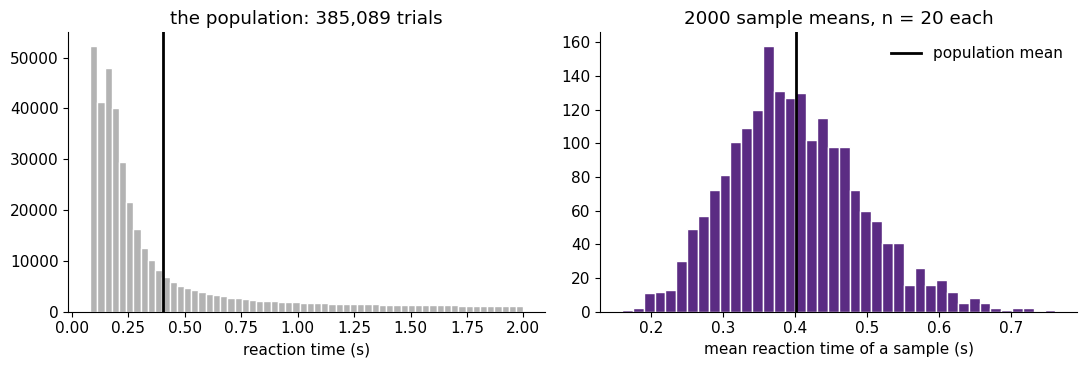

population mean      : 0.4020 s
mean of sample means : 0.3999 s
SD of sample means   : 0.0915 s   <- this is the standard error


In [27]:
# --- Build a sampling distribution by brute force
rng = np.random.default_rng(3)
population = rt.to_numpy()          # our stand-in for "all possible trials"

n_per_sample = 20
n_repeats = 2000
sample_means = np.array([rng.choice(population, size=n_per_sample).mean()
                         for _ in range(n_repeats)])   # the comprehension repeats the draw

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(population, bins=60, color="0.7", edgecolor="white")
axes[0].axvline(population.mean(), color="black", lw=2)  # vertical reference line
axes[0].set_title(f"the population: {len(population):,} trials")
axes[0].set_xlabel("reaction time (s)")

axes[1].hist(sample_means, bins=40, color="#5b2c83", edgecolor="white")
# vertical reference line
axes[1].axvline(population.mean(), color="black", lw=2, label="population mean")
axes[1].set_title(f"{n_repeats} sample means, n = {n_per_sample} each")
axes[1].set_xlabel("mean reaction time of a sample (s)")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"population mean      : {population.mean():.4f} s")
print(f"mean of sample means : {sample_means.mean():.4f} s")
print(f"SD of sample means   : {sample_means.std(ddof=1):.4f} s   <- this is the standard error")

The sampling distribution is **centred** on the population mean, so the sample mean is unbiased,
and it is **much narrower** than the population, because averaging cancels noise. How much
narrower is what the next two sections are about.

<a id="section-2-3"></a>
## 2.3 The Law of Large Numbers

The sample mean converges to the expectation as the sample grows: not "gets close by luck" but
converges, with the wobble shrinking without limit. Add observations one at a time and watch the
running mean settle.

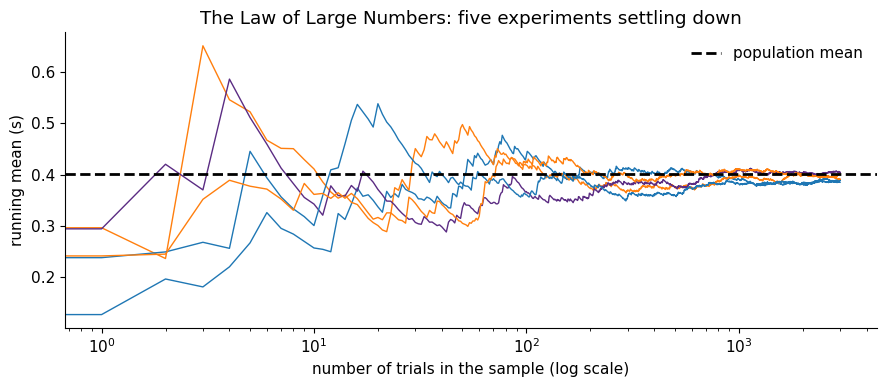

In [28]:
# --- Running mean of a growing sample, five independent repetitions
rng = np.random.default_rng(5)

fig, ax = plt.subplots(figsize=(9, 4))
for repeat in range(5):
    # draw 3000 trials from the population (get at random 3000 values from rt)
    draws = rng.choice(population, size=3000)
    # compute the running mean of the growing sample
    running = np.cumsum(draws) / np.arange(1, draws.size + 1)
    ax.plot(running, lw=1)

# horizontal reference line
ax.axhline(population.mean(), color="black", lw=2, ls="--", label="population mean")
ax.set_xscale("log")
ax.set_xlabel("number of trials in the sample (log scale)")
ax.set_ylabel("running mean (s)")
ax.set_title("The Law of Large Numbers: five experiments settling down")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

<a id="section-2-4"></a>
## 2.4 The Central Limit Theorem

The Law of Large Numbers says where the sample mean ends up. The CLT says what its **shape** is:
whatever the population looks like, the distribution of the sample mean tends to a **Normal** as n
grows. Worth watching here, because our population is emphatically not Normal.

It also gives the width. The standard deviation of the sampling distribution is the **standard
error of the mean**:

$$\text{SEM} \;=\; \frac{\text{SD}}{\sqrt{n}}$$

so quadrupling the sample halves the uncertainty. That square root is why large studies are
expensive.

n =   2: observed SD of means 0.2966, predicted SD/sqrt(n) 0.3037
n =  10: observed SD of means 0.1353, predicted SD/sqrt(n) 0.1358
n = 100: observed SD of means 0.0432, predicted SD/sqrt(n) 0.0430


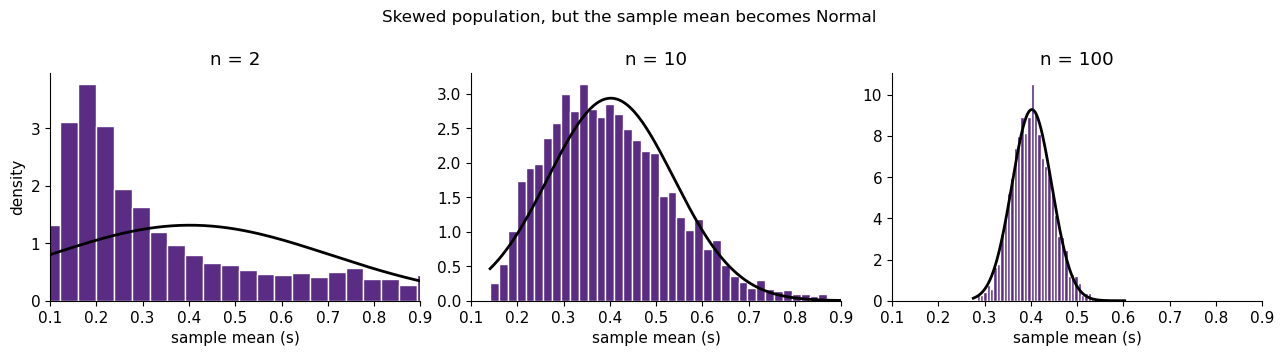

In [29]:
# --- The sampling distribution for three sample sizes, with the predicted SEM
rng = np.random.default_rng(8)
sizes = [2, 10, 100]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, n in zip(axes, sizes):
    # sample 3000 times, each time taking n draws from the population and computing the mean
    means = np.array([rng.choice(population, size=n).mean() for _ in range(3000)])
    # plot the histogram of the sample means
    ax.hist(means, bins=45, density=True, color="#5b2c83", edgecolor="white")

    # the Normal the CLT predicts
    # create a grid of 200 points between the min and max of the sample means
    grid = np.linspace(means.min(), means.max(), 200)
    # the standard error this sample size predicts, SD / sqrt(n)
    # (ddof=1 divides by n - 1, the sample rather than the population formula)
    predicted_sem = population.std(ddof=1) / np.sqrt(n)
    # the Normal density on that grid, written out rather than imported
    normal_pdf = np.exp(-0.5 * ((grid - population.mean()) / predicted_sem) ** 2) / (
        predicted_sem * np.sqrt(2 * np.pi))
    ax.plot(grid, normal_pdf, color="black", lw=2) # plot the Normal PDF on top of the histogram

    ax.set_title(f"n = {n}")
    ax.set_xlabel("sample mean (s)")
    print(f"n = {n:>3}: observed SD of means {means.std(ddof=1):.4f}, "
          f"predicted SD/sqrt(n) {predicted_sem:.4f}")

axes[0].set_ylabel("density")
axes[0].set_xlim(0.1, 0.9)  # set the range of the horizontal axis
# one title for the whole figure
fig.suptitle("Skewed population, but the sample mean becomes Normal", fontsize=12)
fig.tight_layout()
plt.show()

At n = 2 the histogram is still lopsided, inherited from the population. By n = 100 it is hard to
tell apart from the black curve, and the observed width matches SD/sqrt(n) at every step.

<a id="section-2-5"></a>
## 2.5 SD versus SEM

The most consequential distinction in the notebook, and the commonest mistake in published
figures.

- the **SD** describes the **data**: how much observations differ from each other. It does not
  shrink when you collect more data.
- the **SEM** describes your **estimate**: how much the mean would move if you ran the experiment
  again. It shrinks as sqrt(n).

Both are drawn as error bars and look identical, so a caption has to say which one it is.

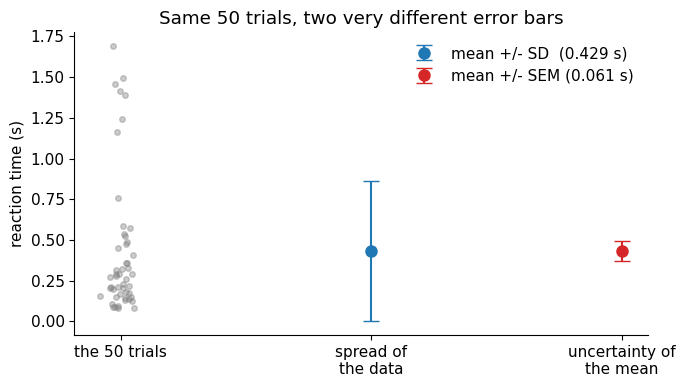

SD  = 0.4291 s   (would not shrink with more trials)
SEM = 0.0607 s   (would halve if we collected 4x as many)


In [30]:
# --- The same data, two error bars, two different claims
rng = np.random.default_rng(13)
# sample 50 trials from the population (get at random 50 values from rt)
sample = rng.choice(population, size=50)

# compute the standard deviation of the sample (ddof=1 to have degrees of freedom = n - 1)
sd = sample.std(ddof=1)
sem = sd / np.sqrt(sample.size) # compute the standard error of the mean (SEM) for the sample size n

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.full(sample.size, 0) + rng.normal(0, 0.03, sample.size), sample,
        "o", ms=4, alpha=0.4, color="0.5")
ax.errorbar([1], [sample.mean()], yerr=[sd], fmt="o", capsize=6, ms=8,
            color="#1f77b4", label=f"mean +/- SD  ({sd:.3f} s)")
ax.errorbar([2], [sample.mean()], yerr=[sem], fmt="o", capsize=6, ms=8,
            color="#d62728", label=f"mean +/- SEM ({sem:.3f} s)")
ax.set_xticks([0, 1, 2])  # choose where the ticks go
# choose what the ticks say
ax.set_xticklabels(["the 50 trials", "spread of\nthe data", "uncertainty of\nthe mean"])
ax.set_ylabel("reaction time (s)")
ax.set_title("Same 50 trials, two very different error bars")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"SD  = {sd:.4f} s   (would not shrink with more trials)")
print(f"SEM = {sem:.4f} s   (would halve if we collected 4x as many)")

> **▶ Task 2.1 ⭐⭐ - Complete the sampling-distribution loop.**
> Complete the function `sampling_distribution(population, n, repeats, rng)` below so that it
> returns an array of `repeats` sample means, each from `n` values drawn from `population`. Then use it to
> check the sqrt(n) law directly: for n in 5, 20, 80, 320, compute the SD of the sample means and
> print it next to `population.std(ddof=1) / np.sqrt(n)`.
>
> Each time n is multiplied by 4, what happens to the standard error?

In [31]:
# TODO 2.1 - fill in the blanks marked ____, uncomment, and run.

# def sampling_distribution(population, n, repeats, rng):
#     """Return `repeats` means of samples of size n drawn from population."""
#     return np.array([____ for _ in range(repeats)])   # (1) mean of rng.choice(population, size=n)
#
# rng = np.random.default_rng(21)
# print(f"{'n':>5} {'observed':>10} {'SD/sqrt(n)':>12}")
# for n in [5, 20, 80, 320]:
#     means = sampling_distribution(population, n, 2000, rng)
#     print(f"{n:>5} {means.std(ddof=1):>10.4f} {____:>12.4f}")   # (2) the predicted SD/sqrt(n)

# Then answer here: each time n is multiplied by 4, what happens to the standard error?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def sampling_distribution(population, n, repeats, rng):
    """Return `repeats` means of samples of size n drawn from population."""
    return np.array([rng.choice(population, size=n).mean() for _ in range(repeats)])

rng = np.random.default_rng(21)
print(f"{'n':>5} {'observed':>10} {'SD/sqrt(n)':>12}")
for n in [5, 20, 80, 320]:
    means = sampling_distribution(population, n, 2000, rng)
    print(f"{n:>5} {means.std(ddof=1):>10.4f} "
          f"{population.std(ddof=1) / np.sqrt(n):>12.4f}")
# Every fourfold increase in n halves the standard error, because sqrt(4) = 2.
# --- END SOLUTION

    n   observed   SD/sqrt(n)
    5     0.1960       0.1921
   20     0.0921       0.0961
   80     0.0476       0.0480
  320     0.0246       0.0240


> **▶ Task 2.2 ⭐⭐ - Standardise a value.**
> The **z-score** of an observation says how many standard deviations it sits from the mean:
> $z = (x - \mu)/\sigma$. It is how you compare things measured on different scales.
> 1. Compute the z-score of a 1.2 s reaction time with respect to the cleaned population.
> 2. Compute the z-score of a *sample mean* of 1.2 s from 20 trials, this time using the SEM
>    rather than the SD as the denominator.
> 3. The two answers are wildly different. Explain in a comment which question each one answers.

In [32]:
# TODO 2.2 - fill in the blanks marked ____, uncomment, and run.

# mu = population.mean()
# sigma = population.std(ddof=1)
# sem20 = ____                                  # (1) the standard error for a sample of 20
#
# z_single = (1.2 - mu) / ____                  # (2) a single trial: divide by the SD
# z_mean = (1.2 - mu) / ____                    # (3) a mean of 20 trials: divide by the SEM
#
# print(f"z of a single 1.2 s trial       : {z_single:.2f}")
# print(f"z of a 1.2 s mean over 20 trials: {z_mean:.2f}")

# Then answer here: the two numbers are very different. Which question does each one answer?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
mu = population.mean()
sigma = population.std(ddof=1)
sem20 = sigma / np.sqrt(20)

z_single = (1.2 - mu) / sigma
z_mean = (1.2 - mu) / sem20

print(f"population mean {mu:.3f} s, SD {sigma:.3f} s, SEM for n=20 {sem20:.3f} s")
print(f"z of a single 1.2 s trial      : {z_single:.2f}")
print(f"z of a 1.2 s mean over 20 trials: {z_mean:.2f}")
# The first asks "is this trial unusual for a mouse?", and the answer is only mildly: slow
# trials like this happen often. The second asks "could a whole 20-trial average land here by
# chance?", and the answer is essentially never, because averages barely move. Same number,
# two completely different questions, and the denominator is what distinguishes them.
# --- END SOLUTION

population mean 0.402 s, SD 0.430 s, SEM for n=20 0.096 s
z of a single 1.2 s trial      : 1.86
z of a 1.2 s mean over 20 trials: 8.31


<a id="section-3"></a>
# Part 3. Describing the real data

Now thirty real mice. Note what we will *not* do this week: no p-values, no claims of
significance. We describe what is there and set up the question Week 4 answers.

The box plots and violins from section 1.4 come back here, used to compare groups rather than to
look at one variable on its own.

<a id="section-3-1"></a>
## 3.1 Reaction times by cohort

In [33]:
# --- Summary table of cleaned reaction times, per cohort
clean = trials[trials["reaction_time_s"].between(0.08, 2.0)]   # keep only the valid window
print("valid trials:", len(clean))

# Step 1: split the reaction times into one group per cohort.
grouped = clean.groupby("cohort")["reaction_time_s"]

# Step 2: ask for four statistics at once, giving each result column a name of our own.
summary = grouped.agg(n="size", mean="mean", median="median", sd="std")
print("\nafter the first four statistics:")
print(summary.round(3))

# Step 3: the quartiles need an argument, so they come as two separate calls. Each result
# carries the same cohort index, and pandas lines the two sides up by label, not by position.
summary["q25"] = grouped.quantile(0.25)      # the value below which 25% of trials fall
summary["q75"] = grouped.quantile(0.75)      # and below which 75% fall

# Step 4: the interquartile range is just the distance between them.
summary["IQR"] = summary["q75"] - summary["q25"]

# Step 5: put the cohorts in our usual order rather than alphabetical.
summary = summary.reindex(COHORT_ORDER)

print("\nthe finished table:")
print(summary.round(3).to_string())

valid trials: 385089



after the first four statistics:
              n   mean  median     sd
cohort                               
CSHL-WT  112388  0.389   0.185  0.455
CSP-ASD  153161  0.396   0.226  0.408
NYU-WT   119540  0.422   0.235  0.431

the finished table:
              n   mean  median     sd    q25    q75    IQR
cohort                                                    
CSHL-WT  112388  0.389   0.185  0.455  0.105  0.432  0.327
NYU-WT   119540  0.422   0.235  0.431  0.165  0.461  0.296
CSP-ASD  153161  0.396   0.226  0.408  0.155  0.433  0.278


one row per mouse, 30 in total:


,cohort,subject_id,reaction_time_s
0,CSHL-WT,CSHL045,0.22355
1,CSHL-WT,CSHL046,0.23870
2,CSHL-WT,CSHL047,0.15580
3,CSHL-WT,CSHL049,0.18670
4,CSHL-WT,CSHL051,0.16600


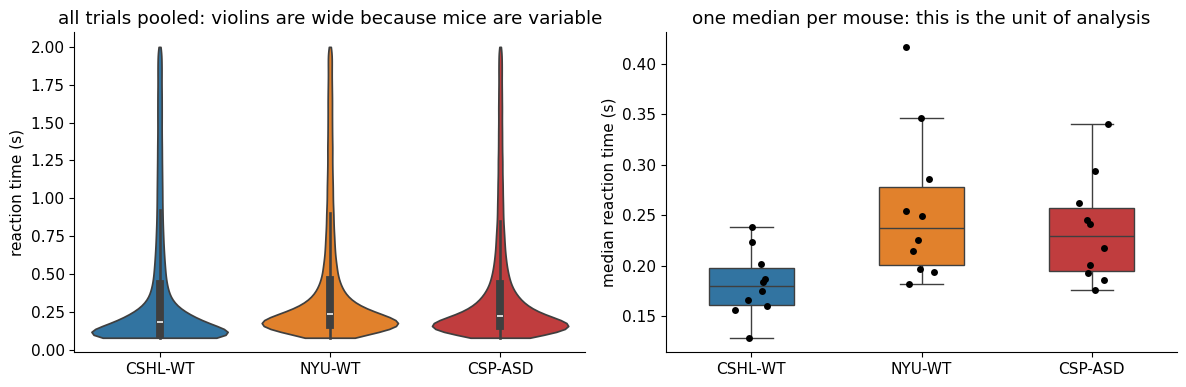

In [34]:
# --- The same three groups, drawn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # create a figure with two panels

# Left panel: every trial is a point, so the violins are built from all 385,000 of them.
sns.violinplot(data=clean, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
               hue="cohort", palette=COHORT_COLOR, legend=False, ax=axes[0], cut=0)
axes[0].set_title("all trials pooled: violins are wide because mice are variable")
axes[0].set_ylabel("reaction time (s)")

# For the right panel we need one number per mouse, so we build it step by step.
grouped_by_mouse = clean.groupby(["cohort", "subject_id"])["reaction_time_s"]  # one group per mouse
per_mouse = grouped_by_mouse.median()          # its median reaction time
per_mouse = per_mouse.reset_index()            # cohort and subject_id become ordinary columns again
print("one row per mouse, 30 in total:")
display(per_mouse.head())

# Right panel: 30 points instead of 385,000, one per animal.
sns.boxplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
            hue="cohort", palette=COHORT_COLOR, legend=False, ax=axes[1],
            width=0.5, fliersize=0)
sns.stripplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
              color="black", size=5, ax=axes[1])                # the individual mice on top
axes[1].set_title("one median per mouse: this is the unit of analysis")
axes[1].set_ylabel("median reaction time (s)")

for ax in axes:
    ax.set_xlabel("")                          # the cohort names speak for themselves
fig.tight_layout()
plt.show()

Both panels show the same data and answer different questions, and the difference matters next
week.

On the left every trial is a point, so n is in the hundreds of thousands. On the right each mouse
contributes **one** number, so n is 30. Trials from one mouse are not independent: same animal,
same training, same cage. Treating them as independent makes any test wildly overconfident, a
mistake common enough to have a name, **pseudoreplication**. The per-mouse panel is the honest
unit, and the one Week 4 tests.

The cell below is meant to redraw the right-hand panel above, one point per mouse. Run it.

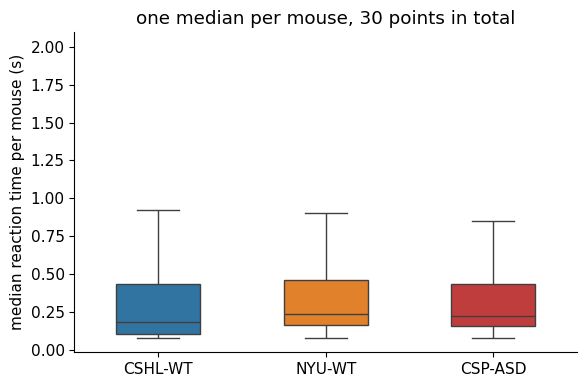

number of values behind this figure: 385089


In [35]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data=clean, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
            hue="cohort", palette=COHORT_COLOR, legend=False, ax=ax, width=0.5, fliersize=0)
ax.set_ylabel("median reaction time per mouse (s)")
ax.set_title("one median per mouse, 30 points in total")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

print("number of values behind this figure:", len(clean))

> **▶ Task 3.1 ⭐⭐ - Repair the figure.**
> It ran, it produced a perfectly respectable looking figure, and it is wrong. Find the mistake, say
> what the picture is actually showing, and draw the right one below.
>
> This is the most dangerous kind of bug: no error message, and a plot that looks like a result.

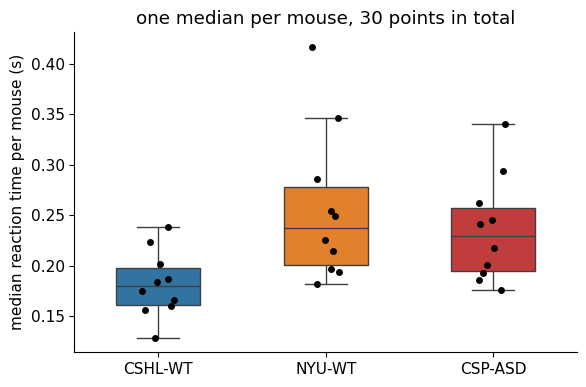

number of values behind this figure: 30


In [36]:
# TODO 3.1 - your corrected figure here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# The bug: the figure is drawn from `clean`, which is one row per TRIAL, while the label and the
# title claim one number per mouse. The boxes are built from 385,000 values instead of 30, so the
# picture describes trial-to-trial variability and calls it between-mouse variability.
# The fix is to draw `per_mouse`, the table built in the previous cell.
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
            hue="cohort", palette=COHORT_COLOR, legend=False, ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
              color="black", size=5, ax=ax)
ax.set_ylabel("median reaction time per mouse (s)")
ax.set_title("one median per mouse, 30 points in total")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

print("number of values behind this figure:", len(per_mouse))
# --- END SOLUTION


Reaction times are right-skewed, which we saw in Part 1. A standard move is to describe them on
a **logarithmic** scale, where the distribution becomes much more symmetric and the mean and
median move back together. This is the log from Week 2, doing real work.

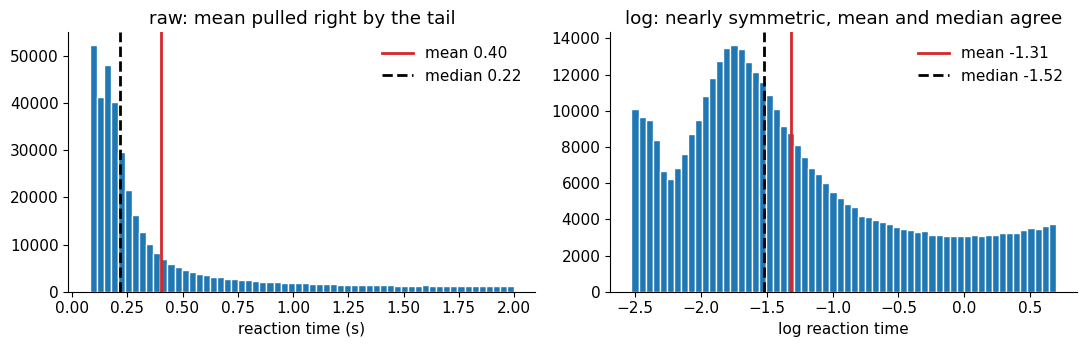

In [37]:
# --- Raw versus log reaction times
log_rt = np.log(clean["reaction_time_s"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, values, name in [(axes[0], clean["reaction_time_s"], "reaction time (s)"),
                         (axes[1], log_rt, "log reaction time")]:
    ax.hist(values, bins=60, color="#1f77b4", edgecolor="white")
    ax.axvline(values.mean(), color="#d62728", lw=2, label=f"mean {values.mean():.2f}")
    ax.axvline(values.median(), color="black", lw=2, ls="--",  # vertical reference line
               label=f"median {values.median():.2f}")
    ax.set_xlabel(name); ax.legend(frameon=False)
axes[0].set_title("raw: mean pulled right by the tail")
axes[1].set_title("log: nearly symmetric, mean and median agree")
fig.tight_layout()
plt.show()

<a id="section-3-2"></a>
## 3.2 Learning curves

The `training` phase holds each mouse's complete history on the basic task, from its first
session to the day it graduated. Averaging accuracy within each session gives a **learning
curve**, and it has the shape Week 2 spent time on: a rise towards an asymptote.

We build it with the `groupby` from section 0. One thing worth repeating: `groupby` on its own
only splits the table into groups and gives you back an object, not numbers. The numbers appear
when you add the operation, `.mean()` here, which pandas applies inside each group before putting
the results back together.

In [38]:
# --- Accuracy per session, for every mouse
training = trials[trials["phase"] == "training"]        # the learning history only
print("training trials:", len(training))

# Step 1: group by cohort, mouse and session. Three keys, so one group per mouse per session.
grouped_sessions = training.groupby(["cohort", "subject_id", "session"])["correct"]

# Step 2: the mean of `correct` inside a group is that session's accuracy.
curve = grouped_sessions.mean()
print("\nthe three grouping keys are now the index:")
display(curve.head())

# Step 3: turn them back into ordinary columns, which is what plotting needs.
curve = curve.reset_index()
print("\nthe same numbers as a flat table:")
display(curve.head())

training trials: 508695

the three grouping keys are now the index:


cohort   subject_id  session
CSHL-WT  CSHL045     1          0.540146
                     2          0.431818
                     3          0.459807
                     4          0.363881
                     5          0.409766
Name: correct, dtype: float64


the same numbers as a flat table:


,cohort,subject_id,session,correct
0,CSHL-WT,CSHL045,1,0.540146
1,CSHL-WT,CSHL045,2,0.431818
2,CSHL-WT,CSHL045,3,0.459807
3,CSHL-WT,CSHL045,4,0.363881
4,CSHL-WT,CSHL045,5,0.409766


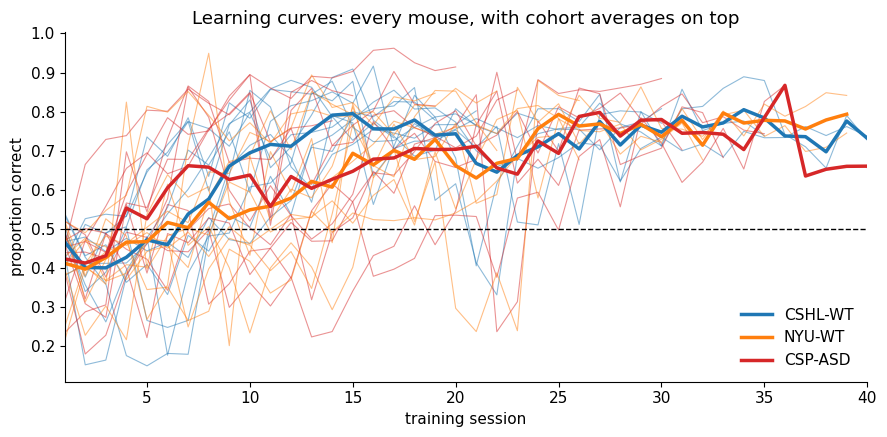

sessions per mouse: 14 to 64, median 25


In [39]:
# --- Plot the learning curve per mouse

fig, ax = plt.subplots(figsize=(9, 4.5))
# loop over each mouse in each cohort, and get the corresponding rows of the curve table
for (cohort, mouse), piece in curve.groupby(["cohort", "subject_id"]):
    # piece is a small DataFrame with the rows for this mouse that we want to plot
    ax.plot(piece["session"], piece["correct"], lw=0.8, alpha=0.5,
            color=COHORT_COLOR[cohort])

# the cohort averages on top, session by session
for cohort in COHORT_ORDER:
    avg = curve[curve["cohort"] == cohort].groupby("session")["correct"].mean()
    ax.plot(avg.index, avg.values, lw=2.5, color=COHORT_COLOR[cohort], label=cohort)

ax.axhline(0.5, color="black", lw=1, ls="--")  # horizontal reference line
ax.set_xlabel("training session")
ax.set_ylabel("proportion correct")
ax.set_title("Learning curves: every mouse, with cohort averages on top")
ax.set_xlim(1, 40)  # set the range of the horizontal axis
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

n_sessions = training.groupby("subject_id")["session"].max()
print(f"sessions per mouse: {n_sessions.min()} to {n_sessions.max()}, "
      f"median {n_sessions.median():.0f}")

Two honest observations. The individual curves are noisy and the mice differ a lot, which is what
real learning data look like. And the cohort averages get unreliable at the right-hand edge, where
only the slowest learners remain: the average at session 40 rests on a handful of animals. That is
**survivorship** inside a group average, and you catch it by plotting the individuals.

<a id="section-3-3"></a>
## 3.3 Psychometric curves

The summary of a perceptual experiment: the probability of choosing "right" against the signed
contrast. This is the sigmoid from Week 2, measured rather than invented. Its **midpoint** is
where the mouse is indifferent, its **steepness** how sharply it discriminates.

trained trials, no-go excluded: 184581

one row per mouse per contrast:


,cohort,subject_id,signed_contrast,response
0,CSHL-WT,CSHL045,-1.0000,0.021907
1,CSHL-WT,CSHL045,-0.2500,0.055629
2,CSHL-WT,CSHL045,-0.1250,0.161028
3,CSHL-WT,CSHL045,-0.0625,0.346154
4,CSHL-WT,CSHL045,0.0000,0.560861


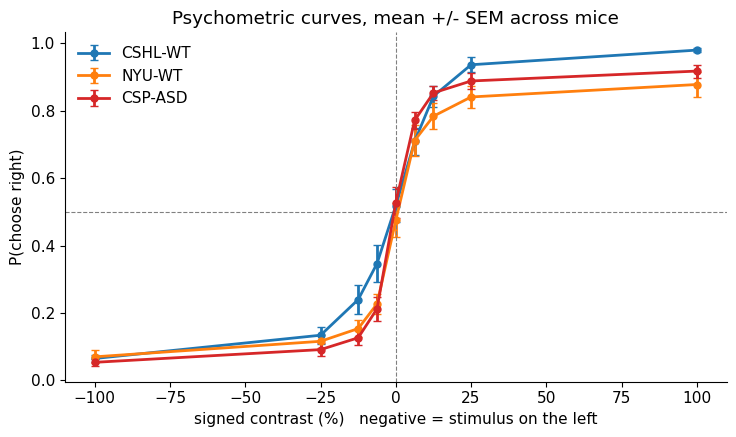

In [40]:
# --- Psychometric curve per cohort, from the trained phase
trained = trials[(trials["phase"] == "trained") & (~trials["no_go"])]   # ~ means "not"
print("trained trials, no-go excluded:", len(trained))

# Step 1: one group per mouse per contrast level.
grouped_psy = trained.groupby(["cohort", "subject_id", "signed_contrast"])["response"]

# Step 2: `response` is 1 for a rightward choice, so its mean is P(choose right).
per_mouse_psy = grouped_psy.mean().reset_index()
print("\none row per mouse per contrast:")
display(per_mouse_psy.head())

fig, ax = plt.subplots(figsize=(7.5, 4.5))  # create a figure and its panel

for cohort in COHORT_ORDER:
    piece = per_mouse_psy[per_mouse_psy["cohort"] == cohort]      # just this cohort's mice
    avg = piece.groupby("signed_contrast")["response"].agg(["mean", "sem"])   # across mice
    ax.errorbar(avg.index * 100, avg["mean"], yerr=avg["sem"], marker="o", ms=5,
                lw=2, capsize=3, color=COHORT_COLOR[cohort], label=cohort)

ax.axhline(0.5, color="gray", lw=0.8, ls="--")  # horizontal reference line at chance
ax.axvline(0, color="gray", lw=0.8, ls="--")    # vertical reference line at zero contrast
ax.set_xlabel("signed contrast (%)   negative = stimulus on the left")
ax.set_ylabel("P(choose right)")
ax.set_title("Psychometric curves, mean +/- SEM across mice")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The error bars are SEMs across **mice**, so the n behind them is 10 per cohort, not the number of
trials. Same choice as in 3.1, and it is what keeps the figure honest.

<a id="section-3-4"></a>
## 3.4 A group difference, described

The comparison the dataset was built for.

In the `trained` phase the stimulus is not equally likely on both sides. The experiment runs in
**blocks**, and inside a block the chance it appears on the left is either 0.2 or 0.8. Nobody
tells the mouse when a block changes, but a good learner notices and leans towards the likely
side. That leaning is clearest on **zero-contrast** trials, where there is nothing to see and the
prior is all there is.

So each mouse gives one number: how far its choices shift between the two block types at zero
contrast, the **prior-updating shift**. Ignore the blocks and it is near zero; exploit them fully
and it is large.

Ten of the Angelaki mice are wild-type (`NYU-WT`) and ten carry the Cntnap2 mutation (`CSP-ASD`),
so a difference between those two is not confounded by the lab. This is where they are expected to
differ, and what Week 4 will test.

We describe it and stop: no test, no p-value. What we can do is make it unit-free, by dividing by
the spread of the data:

$$d \;=\; \frac{\bar{x}_A - \bar{x}_B}{s_{\text{pooled}}}$$

Read it as "the groups differ by d standard deviations". The pooled SD here is the two sample SDs weighted by their degrees of freedom, which is the formula the lecture uses and the one Week 4 reuses next week: with equal group sizes it is the same as the simple average of the two variances, but not when the groups differ in size. Note the denominator: the SD **across
mice**, not the SEM. It asks how big the difference is next to how much mice vary, which is
biology. Dividing by the SEM would ask how surprising it is, which is certainty, and that is
Week 4's step.

NB: to compute the shift between blocks we will use `unstack()`. After `groupby()`,
 the grouping variables are stored as index levels and unstack("probability_left") moves the 
 probability_left index level into separate columns, giving one row per mouse and one column
 for each block probability. This makes it easy to compare or subtract the conditions within each mouse.
Before reshaping, the data are in "long format", with each mouse appearing in several rows. 
After reshaping, they are in "wide format", with one row per mouse and one column for each block probability.

In [41]:
# --- The per-mouse prior-updating shift at zero contrast
# Step 1: zero-contrast trials from the biased blocks only (0.5 means an unbiased block).
zero = trained[(trained["signed_contrast"] == 0) & (trained["probability_left"] != 0.5)]
print("zero-contrast trials in biased blocks:", len(zero))

# Step 2: one group per mouse per block type, and the mean of `response` in each.
grouped_blocks = zero.groupby(["cohort", "sex", "subject_id", "probability_left"])["response"]
# notice that this is a Series with a multi-level index, not a DataFrame
long_form = grouped_blocks.mean()
print("\nlong form: two rows per mouse, one per block type")
display(long_form.head(4))

# Step 3: unstack moves the block probability from the index into columns, so that the two
# numbers of one mouse sit side by side on the same row and can be subtracted.
# this is a DataFrame with one row per mouse, and two columns for the two block types
by_block = long_form.unstack("probability_left")
print("\nwide form after unstack: one row per mouse, one column per block type")
display(by_block.head(3))

# Step 4: give the two columns readable names.
by_block.columns = [f"p_right_pleft_{c}" for c in by_block.columns]

# Step 5: the shift is the difference between the two block types.
by_block["shift"] = by_block["p_right_pleft_0.2"] - by_block["p_right_pleft_0.8"]
shift = by_block.reset_index()                  # cohort, sex and subject_id back as columns

print("\nthe per-mouse shift, by cohort:")
print(shift.groupby("cohort")["shift"]
           .agg(n="size", mean="mean", sd="std").reindex(COHORT_ORDER).round(4).to_string())

zero-contrast trials in biased blocks: 32376

long form: two rows per mouse, one per block type


cohort   sex  subject_id  probability_left
CSHL-WT  F    CSHL051     0.2                 0.762681
                          0.8                 0.303653
              CSHL053     0.2                 0.574503
                          0.8                 0.223622
Name: response, dtype: float64


wide form after unstack: one row per mouse, one column per block type


probability_left             0.2       0.8
cohort  sex subject_id                    
CSHL-WT F   CSHL051     0.762681  0.303653
            CSHL053     0.574503  0.223622
            CSHL054     0.690972  0.254766


the per-mouse shift, by cohort:
          n    mean      sd
cohort                     
CSHL-WT  10  0.3902  0.1108
NYU-WT   10  0.2924  0.0752
CSP-ASD  10  0.2265  0.0530


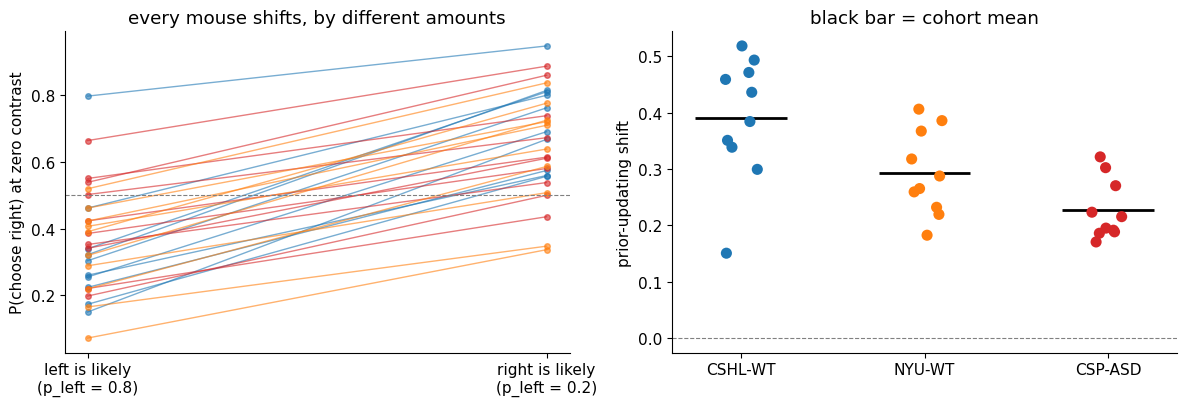

In [42]:
# --- One dot per mouse: how much each animal leans on the block prior
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# left: the choices themselves, one line per mouse, in the two block types
# One row per mouse in the shift table, so only thirty of them: this is the rare case
# where walking a table row by row with iterrows is fine.
for _, row in shift.iterrows():
    axes[0].plot([0, 1], [row["p_right_pleft_0.8"], row["p_right_pleft_0.2"]],
                 "-o", ms=4, lw=1, alpha=0.6, color=COHORT_COLOR[row["cohort"]])
axes[0].set_xticks([0, 1])  # choose where the ticks go
# choose what the ticks say
axes[0].set_xticklabels(["left is likely\n(p_left = 0.8)", "right is likely\n(p_left = 0.2)"])
axes[0].set_ylabel("P(choose right) at zero contrast")
axes[0].axhline(0.5, color="gray", lw=0.8, ls="--")  # horizontal reference line
axes[0].set_title("every mouse shifts, by different amounts")

# right: the shift itself, one number per mouse
sns.stripplot(data=shift, x="cohort", y="shift", order=COHORT_ORDER, hue="cohort",
              palette=COHORT_COLOR, legend=False, size=8, ax=axes[1])
for i, cohort in enumerate(COHORT_ORDER):
    values = shift.loc[shift["cohort"] == cohort, "shift"]
    axes[1].hlines(values.mean(), i - 0.25, i + 0.25, color="black", lw=2)
axes[1].axhline(0, color="gray", lw=0.8, ls="--")  # horizontal reference line
axes[1].set_xlabel(""); axes[1].set_ylabel("prior-updating shift")
axes[1].set_title("black bar = cohort mean")

fig.tight_layout()
plt.show()

> **▶ Task 3.2 ⭐⭐⭐ - Describe the difference, standardised.**
> Complete the function below so that it returns the difference between two groups in units of
> their pooled standard deviation, then apply it to the genotype comparison (`NYU-WT` against
> `CSP-ASD`) and to the lab comparison between the two wild-type cohorts. The SEM version is
> written for you.
>
> Then answer in a comment: which of the two columns says the effect is **large**, and which says
> it is **hard to explain by chance**? Why are those different questions?

In [43]:
# TODO 3.2 - fill in the blanks marked ____, uncomment, and run.

# def standardised_difference(a, b):
#     """Difference between two groups, in units of their pooled standard deviation."""
#     n_a, n_b = len(a), len(b)
#     # the pooled variance, the two sample variances weighted by their degrees of freedom
#     pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
#     pooled_sd = np.sqrt(pooled_var)
#     return ____                          # (1) difference of the means, divided by pooled_sd
#
# def difference_in_sem(a, b):
#     """The same difference, in units of the standard error instead."""
#     n_a, n_b = len(a), len(b)
#     # the pooled variance, the two sample variances weighted by their degrees of freedom
#     pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
#     pooled_sd = np.sqrt(pooled_var)
#     sem = pooled_sd * np.sqrt(1 / len(a) + 1 / len(b))
#     return (np.mean(a) - np.mean(b)) / sem
#
# groups = {c: shift.loc[shift["cohort"] == c, "shift"].to_numpy() for c in COHORT_ORDER}
#
# for label, a, b in [("genotype", "NYU-WT", "CSP-ASD"),
#                     ("lab", ____, ____)]:            # (2) the two wild-type cohorts
#     print(f"{label:9s} in SD units {standardised_difference(groups[a], groups[b]):6.3f}"
#           f"   in SEM units {difference_in_sem(groups[a], groups[b]):6.3f}")

# Then answer here: which column says the effect is large, and which says it is hard to
# explain by chance? Why are those not the same question?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def standardised_difference(a, b):
    """Difference between two groups, in units of their pooled standard deviation."""
    n_a, n_b = len(a), len(b)
    # the pooled variance, the two sample variances weighted by their degrees of freedom
    pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    pooled_sd = np.sqrt(pooled_var)
    return (np.mean(a) - np.mean(b)) / pooled_sd

def difference_in_sem(a, b):
    """The same difference, in units of the standard error instead."""
    n_a, n_b = len(a), len(b)
    # the pooled variance, the two sample variances weighted by their degrees of freedom
    pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    pooled_sd = np.sqrt(pooled_var)
    sem = pooled_sd * np.sqrt(1 / len(a) + 1 / len(b))
    return (np.mean(a) - np.mean(b)) / sem

groups = {c: shift.loc[shift["cohort"] == c, "shift"].to_numpy() for c in COHORT_ORDER}

rows = []
for label, (a, b) in {"genotype (NYU-WT vs CSP-ASD)": ("NYU-WT", "CSP-ASD"),
                      "lab (CSHL-WT vs NYU-WT)": ("CSHL-WT", "NYU-WT")}.items():
    rows.append({"comparison": label,
                 "raw difference": np.mean(groups[a]) - np.mean(groups[b]),
                 "in SD units": standardised_difference(groups[a], groups[b]),
                 "in SEM units": difference_in_sem(groups[a], groups[b])})
print(pd.DataFrame(rows).round(3).to_string(index=False))

# The "in SD units" column says how big the difference is compared with how much mice vary:
# that is a statement about biology, and it does not change if we test more animals. The
# "in SEM units" column says how far the observed difference sits from zero on the scale of
# our uncertainty: that is a statement about evidence, and it grows as we add mice. A tiny
# effect measured in thousands of animals scores high on the second and low on the first.
# The second column is Cohen's d and the third is essentially a t statistic, which is where
# Week 4 begins.
# --- END SOLUTION

                  comparison  raw difference  in SD units  in SEM units
genotype (NYU-WT vs CSP-ASD)           0.066        1.013         2.266
     lab (CSHL-WT vs NYU-WT)           0.098        1.034         2.312


> **▶ Task 3.3 ⭐⭐⭐ - Rerun the experiment, for real.**
> Part 2 built a sampling distribution by drawing samples with a computer. This dataset contains
> something better: the same experiment really was repeated, once per session, in the same animal.
>
> Take mouse `CSHL051` in the `trained` phase, cleaning its reaction times as in section 3.1.
> Treat **each of its sessions as one repeat of the experiment** and produce:
>
> 1. one **mean** reaction time per session, and how many trials each session contributed;
> 2. a figure showing how that per-session estimate moves from session to session;
> 3. the standard deviation of those session means, next to the standard error you would have
>    predicted from a single session using `SD / sqrt(n)`.
>
> Then answer in a comment: are the two numbers close? If the real spread is larger, what is in the
> data that the resampling of Part 2 assumed away?
>
> There is no skeleton this time, but every step uses something from sections 0, 1 and 2.

8 sessions, 30 to 172 trials each
 session     mean   n
       1 0.203116 172
       2 0.308339  62
       3 0.267324  72
       4 0.258877  64
       5 0.265718 157


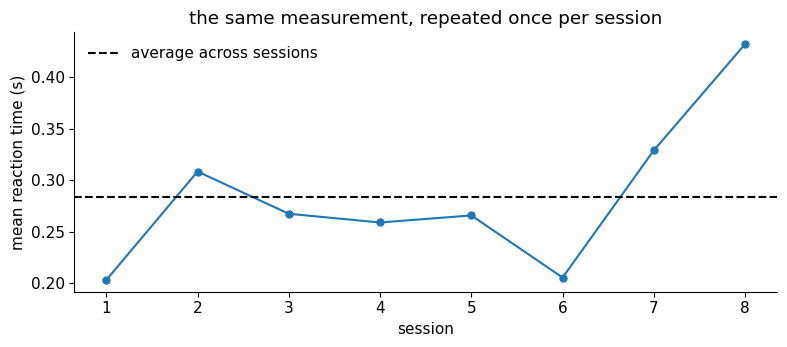

SD of the session means        : 0.0741 s
SD / sqrt(n) from single trials: 0.0333 s
ratio                          : 2.2


In [44]:
# TODO 3.3 - your analysis here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# One mouse, trained phase, valid reaction times only.
one = clean[(clean["subject_id"] == "CSHL051") & (clean["phase"] == "trained")]

# 1. one row per session: the mean reaction time and how many trials it rests on.
# The mean, not the median, because Part 2 built the sampling distribution of the mean and we
# want to compare like with like.
by_session = one.groupby("session")["reaction_time_s"].agg(mean="mean", n="size")
by_session = by_session.reset_index()
print(f"{len(by_session)} sessions, {by_session['n'].min()} to {by_session['n'].max()} trials each")
print(by_session.head().to_string(index=False))

# 2. the estimate, session after session
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(by_session["session"], by_session["mean"], "o-", lw=1.5, ms=5)
ax.axhline(by_session["mean"].mean(), color="black", lw=1.5, ls="--",
           label="average across sessions")
ax.set_xlabel("session")
ax.set_ylabel("mean reaction time (s)")
ax.set_title("the same measurement, repeated once per session")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# 3. observed spread against the prediction from within-session variability
observed = by_session["mean"].std(ddof=1)
predicted = one["reaction_time_s"].std(ddof=1) / np.sqrt(by_session["n"].mean())
print(f"SD of the session means        : {observed:.4f} s")
print(f"SD / sqrt(n) from single trials: {predicted:.4f} s")
print(f"ratio                          : {observed / predicted:.1f}")

# The real spread is more than twice the predicted one here, and it is larger for every one of
# the thirty mice: across the dataset the ratio runs from 1.7 to 17.8, with a median near 4.
# The resampling of Part 2 drew trials at random from a single pool, so sampling was its
# only source of variability. Real sessions also differ from one another: the animal is more or
# less trained, more or less motivated, and the sessions are days apart. That between-session
# variability is invisible to SD / sqrt(n), which assumes every trial is an independent draw from
# one fixed population. It is the pseudoreplication problem of section 3.1, one level up, and it
# is why a confidence interval computed from trials is far too narrow.
# --- END SOLUTION

<a id="section-4"></a>
# 4. What comes next

You can now open a table you have never seen, clean a variable, summarise it appropriately for its
shape, and say how much of what you see is the process and how much is the luck of the draw.

The last task is the bridge. You expressed one difference twice, divided by the standard deviation
and divided by the standard error, and those are the two halves of inference. The first is the
**effect size**, which gets its proper name next week, Cohen's d. The second is a **test
statistic**, and next week we work out how surprising such a value would be if there were no
difference at all. That is a p-value.

Week 4 takes the three comparisons in this dataset, genotype, lab and sex, and asks which
survive a test. One of them is a genuine null, on purpose.